### Extract satellite data at VOR plots for standing biomass modelling

#### Package inputs

In [1]:
import xarray as xr
import rioxarray as riox
import numpy as np
import os
import re
import pandas as pd
import geopandas as gpd
from datetime import datetime, timedelta
from tqdm import tqdm
tqdm.pandas()
import time
import json
from shapely import wkt
from itertools import chain
from hlsstack.hls_funcs.masks import mask_hls, shp2mask, bolton_mask_xr, bolton_mask_np, atsa_mask
from hlsstack.hls_funcs import indices
from hlsstack.hls_funcs.smooth import despike_ts, double_savgol
import gc
from glob import glob
import planetary_computer
import pystac_client
import stackstac
from pyproj import Transformer

In [2]:
import ee

In [3]:
ee.Initialize(
    project='ee-xr-tools',
    opt_url='https://earthengine-highvolume.googleapis.com')

#### Specify parameters

##### Specify input/output paths

In [4]:
# input directory
inDIR = '../data/ground_cln/'

# prefix for plot vs. transect
prefix = 'transect'

# input file for VOR data
inFILE = 'vor_2014_2023_cln_2024_04_04_' + prefix + '.csv'
# create full input path
inPATH = os.path.join(inDIR, inFILE)
# output directory
outDIR = '../data/training/'
# create full output path from input file name
outPATH = os.path.join(outDIR, re.sub('.csv', '_s2_idxs_v7.csv', inFILE))

# make the output directory if it doesn't already exist
if not os.path.exists(outDIR):
    os.mkdir(outDIR)

# path to save raw time series data
outPATH_raw = '../data/raw_tmp/ts_raw_vor_' + prefix + '_s2_v7.csv'

In [5]:
gee_vis = ['NDVI', 
           'mARI', 
           'CHL-RED-EDGE', 
           'EVI', 'MCARI',
           'MSI', 
           'NDMI',
           'NDWI', 
           'NDMI_MoistureStress',
           'NDCI',
           'PSSRb1',
           'SAVI',
           'SIPI',
           'PSRI']

def gee_vi_func(s2Image):
    ndvi = s2Image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    
    ari = s2Image.expression(
        '(1 / B3) - (1 / B5)',
        {
            'B3': s2Image.select('B3'),
            'B5': s2Image.select('B5')
        }
    ).rename('ARI')

    mari = s2Image.expression(
      '((1 / B3) - (1 / B5)) * B7',
      {
        'B3': s2Image.select('B3'),
        'B5': s2Image.select('B5'),
        'B7': s2Image.select('B7')
      }
    ).rename('mARI')

    chlrededge = s2Image.expression(
      '(B7 / B5) - 1',
      {
        'B7': s2Image.select('B7'),
        'B5': s2Image.select('B5')
      }
    ).rename('CHL-RED-EDGE')

    evi = s2Image.expression(
      '2.5 * ((B8 - B4) / (B8 + 6 * B4 - 7.5 * B2 + 1))',
      {
        'B8': s2Image.select('B8'),
        'B4': s2Image.select('B4'),
        'B2': s2Image.select('B2')
      }
    ).rename('EVI')

    gndvi = s2Image.normalizedDifference(['B8', 'B3']).rename('GNDVI')

    mcari = s2Image.expression(
      '((B5 - B4) - 0.2 * (B5 - B3)) * (B5 / B4)',
      {
        'B5': s2Image.select('B5'),
        'B4': s2Image.select('B4'),
        'B3': s2Image.select('B3')
      }
    ).rename('MCARI')

    msi = s2Image.expression(
      'B11 / B8',
      {
        'B11': s2Image.select('B11'),
        'B8': s2Image.select('B8')
      }
    ).rename('MSI')

    ndmi = s2Image.normalizedDifference(['B8A', 'B11']).rename('NDMI')
    
    ndwi = s2Image.normalizedDifference(['B3', 'B8']).rename('NDWI')

    ndmiMoisture = s2Image.normalizedDifference(['B8', 'B11']).rename('NDMI_MoistureStress')

    ndci = s2Image.normalizedDifference(['B5', 'B4']).rename('NDCI')

    pssrb1 = s2Image.expression('B8 / B4', {
      'B8': s2Image.select('B8'),
      'B4': s2Image.select('B4')
    }).rename('PSSRb1')

    savi = s2Image.expression(
      '(B8 - B4) / (B8 + B4 + L) * (1 + L)', {
        'B8': s2Image.select('B8'),
        'B4': s2Image.select('B4'),
        'L': 0.428
      }
    ).rename('SAVI')

    sipi = s2Image.expression(
      '(B8 - B1) / (B8 - B4)', {
        'B8': s2Image.select('B8'),
        'B1': s2Image.select('B1'),
        'B4': s2Image.select('B4')
      }
    ).rename('SIPI')

    psri = s2Image.expression(
      '(B4 - B2) / B6', {
        'B4': s2Image.select('B4'),
        'B2': s2Image.select('B2'),
        'B6': s2Image.select('B6')
      }
    ).rename('PSRI')
    
    return s2Image.addBands(
        ndvi).addBands(
        ari).addBands(
        mari).addBands(
        chlrededge).addBands(
        evi).addBands(
        gndvi).addBands(
        mcari).addBands(
        msi).addBands(
        ndmi).addBands(
        ndwi).addBands(
        ndmiMoisture).addBands(
        ndci).addBands(
        pssrb1).addBands(
        savi).addBands(
        sipi).addBands(
        psri)

In [6]:
def gee_s1_func(s1Image):
    #Convert from dB to linear scale
    vv = s1Image.select('VV')
    vh = s1Image.select('VH')
    vv_sig = ee.Image(10).pow(s1Image.select('VV').divide(10)).rename('VV_sig')
    vh_sig = ee.Image(10).pow(s1Image.select('VH').divide(10)).rename('VH_sig')
    
    # sum formula
    vhvv_sum = s1Image.expression(
    '(vh + vv)', {
      'vv': vv,
      'vh': vh
    }).rename('VHVV_sum');
    
    # difference formula
    vhvv_diff = s1Image.expression(
    '(vh - vv)', {
      'vv': vv,
      'vh': vh
    }).rename('VHVV_diff');
    
    # ratio formula
    vhvv_ratio = s1Image.expression(
    '(vh / vv)', {
      'vv': vv,
      'vh': vh
    }).rename('VHVV_ratio')
    
    # RVI forumla (see Nasirzadehdizaji et al. 2019)
    rvi = s1Image.expression(
    '4 * vh / (vv + vh)', {
      'vv': vv_sig,
      'vh': vh_sig
    }).rename('RVI')
    
    # add an all new bands to the image
    return s1Image.addBands(
      vh).addBands(
      vv).addBands(
      vhvv_sum).addBands(
      vhvv_diff).addBands(
      vhvv_ratio).addBands(
      rvi)

##### Specifiy other parameters

In [7]:
# dask cluster location
cluster_loc = 'local'

# whether to try applying the ATSA cloud/shadow mask
try_atsa = True
# whether to apply the Bolton et al. masking approach
mask_bolton_by_pixel = False
mask_bolton_by_id = True

# whether to save the raw time series data
save_raw = True

# dictionary specifying functions for each vegetation index to calculate and extract
veg_dict = {
    #'NDVI': indices.ndvi_func,
    'DFI': indices.dfi_func,
    'NDTI': indices.ndti_func,
    'SATVI': indices.satvi_func,
    'NDII7': indices.ndii7_func,
    #'SAVI': indices.savi_func,
    'RDVI': indices.rdvi_func,
    'MTVI1': indices.mtvi1_func,
    'NCI': indices.nci_func,
    #'NDCI': indices.ndci_func,
    #'PSRI': indices.psri_func,
    #'NDWI': indices.ndwi_func,
    #'EVI': indices.evi_func,
    #'TCBI': indices.tcbi_func,
    #'TCGI': indices.tcgi_func,
    #'TCWI': indices.tcwi_func,
    #'BAI_126': indices.bai_126_func,
    #'BAI_136': indices.bai_136_func,
    #'BAI_146': indices.bai_146_func,
    #'BAI_236': indices.bai_236_func,
    #'BAI_246': indices.bai_246_func,
    #'BAI_346': indices.bai_346_func
}

# dictionary specifying individual bands to extract
band_list = ['BLUE', 'GREEN', 'RED', 'RED-EDGE1', 'RED-EDGE2', 'RED-EDGE3', 'NIR-Broad', 'NIR1', 'SWIR1', 'SWIR2']

##### Create helper functions

In [8]:
def adapt_smooth(ts, dates, despike=True, dat_thresh=None):
    ct_valid = sum(~np.isnan(ts[(dates.dt.month >= 3) & (dates.dt.month <= 10)]))
    if ct_valid > 0:
        if 180 / ct_valid > 15:
            despike = False
        if despike:
            if dat_thresh is None:
                _dat_thresh = np.ptp(ts.values) * 0.10
            else:
                _dat_thresh = dat_thresh
            ts_ds = despike_ts(ts.values, dat_thresh=_dat_thresh, days_thresh=45)
        else:
            ts_ds = ts.values
        if 180 / ct_valid > 10:
            ts_smooth = double_savgol(ts_ds, double=True, window1_max=7, window2=31, limit=91)
        elif 180 / ct_valid > 7:
             ts_smooth = double_savgol(ts_ds, double=True, window1_max=5, window2=41, limit=91)
        elif 180 / ct_valid > 5:
             ts_smooth = double_savgol(ts_ds, double=True, window1_max=5, window2=51, limit=91)
        else:
            ts_smooth = double_savgol(ts_ds, double=False, window2=51, limit=91)
    else:
        ts_smooth = ts
    return pd.Series(ts_smooth, ts.index.get_level_values(-1))


##### Set up dask cluster

In [9]:
#clust.close()
#client.close()
#!scontrol show nodes

In [10]:
if cluster_loc == 'local':
    print('   setting up Local cluster...')
    from dask.distributed import LocalCluster, Client
    import dask
    from jupyter_server import serverapp
    aws=False
    # don't process on local resources - can't handle ATSA mask
    process_hls=True
    #fetch.setup_env(aws=aws)
    try:
        jupServer = [x for x in serverapp.list_running_servers()][0]
    except IndexError:
        # manually copy/paste the server address
        jupServer = {'base_url': '/node/ceres19-compute-98-eth.scinet.local/17710/'}
    dask.config.set({'distributed.dashboard.link': jupServer['base_url'] + 'proxy/{port}/status'})
    cluster = LocalCluster(n_workers=36, threads_per_worker=2)
    client = Client(cluster)
    display(client)
elif cluster_loc == 'hpc':
    from dask.distributed import LocalCluster, Client
    import dask_jobqueue as jq
    import dask
    from jupyter_server import serverapp
    import psutil
    import distributed
    dask.config.set({"distributed.worker.use-file-locking": False})
    # get the server address for porting
    try:
        jupServer = [x for x in serverapp.list_running_servers()][0]
    except IndexError:
        # manually copy/paste the server address
        jupServer = {'base_url': '/node/ceres19-compute-98-eth.scinet.local/17710/'}
    print('   setting up cluster on HPC...')
    aws=False
    process_hls = True
    fetch.setup_env(aws=aws)
    dask.config.set({'distributed.dashboard.link': jupServer['base_url'] + 'proxy/{port}/status'})
    interface_prefs = [
        #'lo', 
        #'ibp175s0', 
        'enp24s0f0', 
        'ens7f0'
    ]
    interface = [x for x in interface_prefs if x in list(psutil.net_if_addrs().keys())][0]
    if len(interface) == 0:
        print('ERROR: Preferred interfaces not found on node!')
    else:
        print(interface)
    debug=False
    if debug:
        import logging
        logging.basicConfig(format='%(levelname)s:%(message)s', level=logging.DEBUG)
        if not os.path.exists('debug/'):
            os.mkdir('debug/')
        output_cmd = ["--output=debug/slurm-%j.out",
                      "--error=debug/slurm-%j.err"]
    else:
        output_cmd = ["--output=/dev/null",
                      "--error=/dev/null"]
    partition='brief-low',#'short','debug', 'mem', 'mem-low',
    num_processes = 4
    num_threads_per_processes = 2
    mem = 2.5*num_processes*num_threads_per_processes
    n_cores_per_job = num_processes*num_threads_per_processes
    clust = jq.SLURMCluster(queue=partition,
                            processes=num_processes,
                            cores=n_cores_per_job,
                            memory=str(mem) + 'GB',
                            interface=interface,
                            local_directory='$TMPDIR',
                            death_timeout=600.0,
                            walltime='02:00:00',
                            job_extra_directives=["--nodes=1",
                                       #"--nodelist=ceres20-compute-[0-48]",
                                       #"--exclusive",
                                       ] + output_cmd)
    client=Client(clust)
    #Scale Cluster 
    num_jobs=32
    clust.scale(num_jobs)
    try:
        client.wait_for_workers(n_workers=num_jobs*2, timeout=60)
    except dask.distributed.TimeoutError as e:
        print(str(num_jobs*2) + ' workers not available. Continuing with available workers.')
        #print(e)
        pass
    display(client)

   setting up Local cluster...


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /node/atlas-0025/13232/proxy/8787/status,
Dashboard: /node/atlas-0025/13232/proxy/8787/status,Workers: 36
Total threads: 72,Total memory: 270.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43603,Workers: 36
Dashboard: /node/atlas-0025/13232/proxy/8787/status,Total threads: 72
Started: Just now,Total memory: 270.21 GiB
Comm: tcp://127.0.0.1:46061,Total threads: 2
Dashboard: /node/atlas-0025/13232/proxy/36203/status,Memory: 7.51 GiB
Nanny: tcp://127.0.0.1:43415,


#### Load and prepare datasets

In [11]:
### load csv of ground data as GeoDataFrame
# load data and parse dates
df_vor = pd.read_csv(inPATH, parse_dates=[2, 3])
# rename ID column
df_vor = df_vor.rename(columns={'Id_' + prefix: 'Id'})
# remove any data without geometry
df_vor = df_vor[df_vor['geometry'].notnull()].copy()
# convert string geometry to geometry
df_vor['geometry'] = df_vor['geometry'].astype('str').apply(wkt.loads)
# convert to GeoDataFrame
gdf_vor = gpd.GeoDataFrame(df_vor, geometry='geometry', crs=32613)
# sort by date
gdf_vor = gdf_vor.sort_values('Date')

In [12]:
gdf_vor = gdf_vor[gdf_vor['Year'] >= 2018]

In [13]:
# load any existing output data
if os.path.exists(outPATH):
    df_out = pd.read_csv(outPATH, parse_dates=[2, 3])
else:
    df_out = None
# load any existing output data
if os.path.exists(outPATH_raw):
    df_out_raw = pd.read_csv(outPATH_raw, parse_dates=[1])
else:
    df_out_raw = None

In [14]:
from json.decoder import JSONDecodeError
from rasterio.errors import RasterioIOError

In [15]:
gdf_vor

,Id,Pasture,Date,Date_mean,Year,Season,Low,High,Biomass_kg_ha,geometry
1910,20NW_P6_3,20NW,2018-06-01,2018-06-02,2018,June,7.69,26.44,1670.610529,"POLYGON ((526524.494 4519438.598, 526524.422 4..."
1918,20SE_P2_3,20SE,2018-06-01,2018-06-03,2018,June,10.69,55.50,2593.132254,"POLYGON ((526474.310 4518272.166, 526474.238 4..."
1917,20SE_P2_2,20SE,2018-06-01,2018-06-03,2018,June,6.25,43.88,1687.830110,"POLYGON ((526580.360 4518168.166, 526580.288 4..."
1915,20SE_P1_4,20SE,2018-06-01,2018-06-03,2018,June,6.88,43.81,1795.168896,"POLYGON ((526301.325 4518189.179, 526301.253 4..."
1914,20SE_P1_3,20SE,2018-06-01,2018-06-03,2018,June,10.31,52.00,2480.680453,"POLYGON ((526195.275 4518189.179, 526195.203 4..."
...,...,...,...,...,...,...,...,...,...,...
9152,10S_P4_2,10S,2023-10-24,2023-10-24,2023,October,2.88,31.69,932.608277,"POLYGON ((519418.703 4521245.160, 519418.630 4..."
9153,10S_P4_3,10S,2023-10-24,2023-10-24,2023,October,2.69,28.75,863.199980,"POLYGON ((519312.653 4521349.160, 519312.580 4..."
9154,10S_P4_4,10S,2023-10-24,2023-10-24,2023,October,3.44,41.06,1144.135187,"POLYGON ((519418.703 4521349.160, 519418.630 4..."
9145,10S_P2_3,10S,2023-10-24,2023-10-24,2023,October,3.25,26.31,937.038591,"POLYGON ((519559.297 4521098.580, 519559.224 4..."


In [16]:
s2_band_dict = {'B1': 'COASTAL-AEROSOL',
                'B2': 'BLUE', 
                'B3': 'GREEN', 
                'B4': 'RED', 
                'B5': 'RED-EDGE1',
                'B6': 'RED-EDGE2', 
                'B7': 'RED-EDGE3',
                'B8': 'NIR-Broad',
                'B8A': 'NIR1', 
                'B9': 'WATER-VAPOR',
                'B11': 'SWIR1', 
                'B12': 'SWIR2',
                'SCL': 'SCL'}

load_bands = ['B2', 
              'B3',
              'B4', 
              'B5',
              'B6', 
              'B7',
              'B8',
              'B8A', 
              'B11', 
              'B12']

#keep_bands = ['BLUE',
#              'GREEN',
#              'RED',
#              'RED-EDGE1',
#              'RED-EDGE2',
#              'RED-EDGE3',
#              'NIR-Broad',
#              'NIR1',
#              'SWIR1',
#              'SWIR2'] + gee_vis

In [17]:
def harmonize_to_old(data):
    """
    Harmonize new Sentinel-2 data to the old baseline.

    Parameters
    ----------
    data: xarray.DataArray
        A DataArray with four dimensions: time, band, y, x

    Returns
    -------
    harmonized: xarray.DataArray
        A DataArray with all values harmonized to the old
        processing baseline.
    """
    cutoff = datetime(2022, 1, 25)
    offset = 1000
    bands = [
        "B01",
        "B02",
        "B03",
        "B04",
        "B05",
        "B06",
        "B07",
        "B08",
        "B8A",
        "B09",
        "B10",
        "B11",
        "B12",
    ]

    old = data.sel(time=slice(cutoff))

    to_process = list(set(bands) & set(data.band.data.tolist()))
    new = data.sel(time=slice(cutoff, None)).drop_sel(band=to_process)

    new_harmonized = data.sel(time=slice(cutoff, None), band=to_process).clip(offset)
    new_harmonized -= offset

    new = xr.concat([new, new_harmonized], "band").sel(band=data.band.data.tolist())
    return xr.concat([old, new], dim="time")

In [18]:
def gets2_old(bbox=None, date_range=None, transform_bbox=True, 
           lim=1000, aws=False, stack_chunks=(3660, 3660), proj_epsg=32613, debug=False):   
    if type(bbox) == list:
        bbox = np.array(bbox)
    # run functions
    transformer = Transformer.from_crs('epsg:' + str(proj_epsg), 'epsg:4326')
    if transform_bbox:
        bbox_lon, bbox_lat = transformer.transform(bbox[[0, 2]], bbox[[1, 3]])
        bbox_latlon = list(np.array(list(map(list, zip(bbox_lat, bbox_lon)))).flatten())
    else:
        bbox_latlon = bbox
    URL = 'https://planetarycomputer.microsoft.com/api/stac/v1'
    catalog = pystac_client.Client.open(URL, modifier=planetary_computer.sign_inplace)
    items = catalog.search(
        limit=lim,
        bbox=bbox_latlon,
        collections=['sentinel-2-l2a'],
        datetime=date_range
    ).item_collection()
    if debug:
        print(len(items))
    da = stackstac.stack(items,
                         epsg=proj_epsg,
                         bounds=bbox,
                         resolution=20,
                         chunksize=stack_chunks,
                         assets=load_bands)
    da_adj = harmonize_to_old(da)
    ds = da_adj.to_dataset(dim='band').drop_dims('band')
    return ds


def gets2(bbox=None, date_range=None, 
           stack_chunks=(3660, 3660), proj_epsg=32613, scale=20):
    if type(bbox) == list:
        bbox = np.array(bbox)
        
    [min_x, min_y, max_x, max_y] = bbox
    polygon = ee.Geometry.Polygon(
        [[
            [min_x, min_y],
            [max_x, min_y],
            [max_x, max_y], 
            [min_x, max_y],
            [min_x, min_y]
        ]],
        proj='EPSG:32613', evenOdd=False)
    
    QA_BAND = 'cs_cdf'
    CLEAR_THRESHOLD = 0.85
    keep_bands = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'SCL']
    
    csPlus = ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED')
    
    collectionS2L2 = ee.ImageCollection(
        'COPERNICUS/S2_SR_HARMONIZED').filterDate(
        date_range[0], date_range[1]).linkCollection(
        csPlus, [QA_BAND]).map(lambda img: img.updateMask(img.select(QA_BAND).gte(CLEAR_THRESHOLD))).select(
        keep_bands).filterBounds(
        polygon).map(gee_vi_func)
    
    ds = xr.open_dataset(collectionS2L2, 
                         engine='ee',
                         geometry=polygon, 
                         crs='EPSG:' + str(proj_epsg), 
                         scale=scale).transpose('time', 'Y', 'X').sortby('Y', ascending=False).rename({'X': 'x', 'Y': 'y'})
    #for v in keep_bands:
    #    if v != 'SCL':
    #        ds[v] = ds[v]*0.0001
    ds = ds.where(ds['SCL'].isin([4.,5.]))
    ds = ds.drop('SCL')
    ds = ds.where(ds > 0.0)    
    return ds

def gets1(bbox=None, date_range=None, 
           stack_chunks=(3660, 3660), proj_epsg=32613, scale=20):
    if type(bbox) == list:
        bbox = np.array(bbox)
        
    [min_x, min_y, max_x, max_y] = bbox
    polygon = ee.Geometry.Polygon(
        [[
            [min_x, min_y],
            [max_x, min_y],
            [max_x, max_y], 
            [min_x, max_y],
            [min_x, min_y]
        ]],
        proj='EPSG:32613', evenOdd=False)

    keep_bands = ['VH', 'VV', 'VHVV_sum', 'VHVV_diff', 'VHVV_ratio', 'RVI', 'angle']
    
    collectionS1GRD = ee.ImageCollection(
        'COPERNICUS/S1_GRD').filterDate(
        date_range[0], date_range[1]).filter(
        ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')).filter(
        ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')).filter(
        ee.Filter.eq('instrumentMode', 'IW'))

    collectionS1GRD_asc = collectionS1GRD.filter(
        ee.Filter.eq('orbitProperties_pass', 'ASCENDING')).filterBounds(
        polygon).map(gee_s1_func).select(
        keep_bands)
    collectionS1GRD_desc = collectionS1GRD.filter(
        ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).filterBounds(
        polygon).map(gee_s1_func).select(
        keep_bands)
    
    ds_asc = xr.open_dataset(collectionS1GRD_asc, 
                             engine='ee',
                             geometry=polygon, 
                             crs='EPSG:' + str(proj_epsg), 
                             scale=scale).transpose('time', 'Y', 'X').sortby('Y', ascending=False).rename({'X': 'x', 'Y': 'y'})

    ds_desc = xr.open_dataset(collectionS1GRD_desc, 
                             engine='ee',
                             geometry=polygon, 
                             crs='EPSG:' + str(proj_epsg), 
                             scale=scale).transpose('time', 'Y', 'X').sortby('Y', ascending=False).rename({'X': 'x', 'Y': 'y'})

    ds_asc = ds_asc.assign_coords(orbit=['Ascending'])
    ds_desc = ds_desc.assign_coords(orbit=['Descending'])

    ds_desc_lo = ds_desc.where(ds_desc['angle'] <= 38, drop=True)
    ds_desc_hi = ds_desc.where(ds_desc['angle'] > 38, drop=True)

    ds_asc = ds_asc.rename_vars({x: x+'_asc' for x in list(ds_asc.variables) if x not in list(ds_asc.dims)})
    ds_desc_lo = ds_desc_lo.rename_vars({x: x+'_desc_lo' for x in list(ds_desc_lo.variables) if x not in list(ds_desc_lo.dims)})
    ds_desc_hi = ds_desc_hi.rename_vars({x: x+'_desc_hi' for x in list(ds_desc_hi.variables) if x not in list(ds_desc_hi.dims)})

    ds=xr.combine_by_coords([ds_asc, ds_desc_lo, ds_desc_hi])
    
    #for v in keep_bands:
    #    if v != 'SCL':
    #        ds[v] = ds[v]*0.0001
    #ds = ds.where(ds['SCL'].isin([4.,5.]))
    #ds = ds.drop('SCL')
    #ds = ds.where(ds > 0.0)    
    return ds

In [20]:
gee_s1_vis = ['VH_asc', 'VV_asc', 'VHVV_sum_asc', 'VHVV_diff_asc', 'VHVV_ratio_asc', 'RVI_asc', 'angle_asc',
              'VH_desc_lo', 'VV_desc_lo', 'VHVV_sum_desc_lo', 'VHVV_diff_desc_lo', 'VHVV_ratio_desc_lo', 'RVI_desc_lo', 'angle_desc_lo',
              'VH_desc_hi', 'VV_desc_hi', 'VHVV_sum_desc_hi', 'VHVV_diff_desc_hi', 'VHVV_ratio_desc_hi', 'RVI_desc_hi', 'angle_desc_hi']

In [21]:
all_vis = list(veg_dict.keys()) + gee_vis

In [22]:
scl_goodvals = [4, 5]

#### Run extraction for each year

In [ ]:
for yr in tqdm(gdf_vor['Year'].unique()):
    print(yr)
    # skip if year already in output data
    if df_out is not None and yr in df_out['Year'].unique():
        print('Skipping year - already in output dataset.')
        continue
    else:
        # get subset of vor data for year
        gdf_yr = gdf_vor[gdf_vor['Year'] == yr]
        # set the bounding box for fetching data
        bbox_yr = np.array(gdf_yr.total_bounds) # the entire subset dataset 
        
    
        # get the date range for the fetch as a dictionary
        #start_date = gdf_yr['Date'].min().date() - timedelta(days=30)
        #end_date = gdf_yr['Date'].max().date() + timedelta(days=30)
        start_date = str(yr - 1) + "-11-01"
        end_date = str(yr + 1) + "-03-01"
        datestr = "/".join([start_date, end_date])

        # fetch the data for the entire year's dataset
        s1_ds = gets1(bbox_yr, [start_date, end_date]).load()
        s2_ds = gets2(bbox_yr, [start_date, end_date]).load()
        s2_ds = s2_ds.rename_vars({k:s2_band_dict[k] for k in load_bands})

        # drop pixels with negative values for blue band
        s2_ds = s2_ds.where(s2_ds['BLUE'] > 0)

        # combine any imagery from multiple swaths and get just date of timestamp
        s1_ds = s1_ds.groupby(s1_ds['time'].dt.date).mean(skipna=True)
        s1_ds['date'] = pd.to_datetime(s1_ds['date'])
        s1_ds = s1_ds.rename({'date': 'time'})
        
        # combine S1 and S2 data
        ds_comb = xr.combine_by_coords([s2_ds, s1_ds.drop_dims('orbit')])
        
        #if mask_bolton_by_pixel:
            # compute the bolton mask
        #    s2_bolton_mask = bolton_mask(s2_ds).compute()
            #s2_ds = xr.merge([s2_ds, s2_atsa], join='inner')
        #    s2_ds.where(s2_ds['BOLTON'] == 0, drop=True)

        # compute native S2 mask, including all aerosol flags
        #s2_ds = s2_ds.where(s2_ds['SCL'].isin(scl_goodvals))

        # create an xarray mask from the ground data
        mask_info = gdf_vor.drop_duplicates(subset=['Id', 'Date'])[['Id', 'geometry']].reset_index(drop=True).reset_index().rename(columns={'index': 'id'})
        mask_shp = [(row.geometry, row.id+1) for _, row in mask_info.iterrows()]
        plot_mask = shp2mask(shp=mask_shp, 
                             transform=s2_ds.rio.transform(), 
                             outshape=s2_ds['BLUE'].shape[1:], 
                             xr_object=s2_ds['BLUE'])
        mask_dict = {row.id+1: row.Id for _, row in mask_info.iterrows()}
        mask_dict[0] = 'UNK'
        plot_mask = np.array([mask_dict[i] for i in plot_mask.values.flatten()]).reshape(plot_mask.shape)
        
        # assign the plot id's to the xarray dataset
        ds_comb = ds_comb.assign(Plot=(['y', 'x'], plot_mask)).chunk({'y': 50, 'x': 50})
        ds_comb = ds_comb.set_coords('Plot')
        
        # mask out areas outside ground plots
        ds_comb = ds_comb.where(ds_comb['Plot'] != 'UNK')
        
        # create variable to get percentage of pixels that are NA for a given date
        ds_comb['NA_pct'] = ds_comb['BLUE'].isnull().astype('int') * 1.0
        
        # lazy compute all vegetation indices
        for vegidx in veg_dict:
            ds_comb[vegidx] = veg_dict[vegidx](ds_comb)
        
        # convert to dataframe at plot scale, if any pixels are NA, result is NA with skipna=False
        df_yr = ds_comb[all_vis + band_list + gee_s1_vis + ['NA_pct']].groupby('Plot').mean('stacked_y_x', skipna=True).to_dataframe().reset_index()
        
        # remove all non-plot data
        df_yr = df_yr[df_yr['Plot'] != 'UNK']
        
        # remove any dates where bands are negative
        #df_yr = df_yr[~((df_yr[band_list] < 0).any(axis=1))]
        
        # rename columns to match VOR data
        df_yr = df_yr.rename(columns={'time': 'Date',
                                        'Plot': 'Id'})
        # convert date to datetime
        df_yr['Date'] = pd.to_datetime(df_yr['Date'].dt.date)
        
        # get missing dates for gap-filling
        dates_missing = [x for x in pd.date_range(start_date, end_date).date if x not in df_yr['Date'].dt.date.unique()]
        
        # convert missing dates to a dataframe for combining with veg index data
        df_missing = pd.DataFrame({
            'Id': list(chain.from_iterable([list(np.repeat(x, len(dates_missing))) for x in df_yr['Id'].unique()])),
            'Date': list(chain.from_iterable(dates_missing for x in df_yr['Id'].unique()))})
        
        # combine into one dataframe for gapfilling
        df_yr_ts = pd.concat([df_yr, df_missing]).sort_values(['Id', 'Date'])
        
        # apply Bolton mask to extracted values
        if mask_bolton_by_id:
            ps_bolton = df_yr_ts.groupby('Id').progress_apply(lambda x: bolton_mask_np(x['BLUE'], x['SWIR2']))
            df_yr_ts.loc[df_yr_ts[ps_bolton.droplevel(0) == 1.0].index, all_vis + band_list] = np.nan
        
        # smooth all vegetation indices to gapfill
        for vegidx in all_vis:
            #df_yr_ts[vegidx + '_smooth'] = df_yr_ts.groupby('Id')[vegidx].transform(lambda x: double_savgol(x.values))
            vals_smooth_yr = df_yr_ts.groupby('Id').apply(lambda x: adapt_smooth(x[vegidx], pd.to_datetime(x['Date'])))
            df_yr_ts[vegidx + '_smooth'] = vals_smooth_yr.droplevel(list(np.arange(vals_smooth_yr.index.nlevels-1)))
        for band in band_list:
            #df_yr_ts[band + '_smooth'] = df_yr_ts.groupby('Id')[band].transform(lambda x: double_savgol(x.values))
            vals_smooth_yr = df_yr_ts.groupby('Id').apply(lambda x: adapt_smooth(x[band], pd.to_datetime(x['Date'])))
            df_yr_ts[band + '_smooth'] = vals_smooth_yr.droplevel(list(np.arange(vals_smooth_yr.index.nlevels-1)))
        for s1idx in gee_s1_vis:
            #df_yr_ts[vegidx + '_smooth'] = df_yr_ts.groupby('Id')[vegidx].transform(lambda x: double_savgol(x.values))
            vals_smooth_yr = df_yr_ts.groupby('Id').apply(lambda x: adapt_smooth(x[s1idx], pd.to_datetime(x['Date'])))
            df_yr_ts[s1idx + '_smooth'] = vals_smooth_yr.droplevel(list(np.arange(vals_smooth_yr.index.nlevels-1)))
        
        # convert date to datetime
        df_yr_ts['Date'] = pd.to_datetime(df_yr_ts['Date'])
        
        if save_raw:
            if df_out_raw is not None:
                # merge with existing output dataset
                df_out_raw = pd.concat([df_out_raw, df_yr_ts])
            else:
                df_out_raw = df_yr_ts.copy()
            df_out_raw.to_csv(outPATH_raw, index=False)
        
        # rename smoothed columns and drop originals
        df_yr_ts = df_yr_ts.drop(columns=list(all_vis + band_list + gee_s1_vis))
        col_rename_dict = {c: re.sub('_smooth', '', c) for c in df_yr_ts.columns if '_smooth' in c}
        df_yr_ts = df_yr_ts.rename(columns=col_rename_dict)
        
        df_out_yr = pd.merge(gdf_yr, 
                             df_yr_ts[['Id', 'Date'] + all_vis + band_list + gee_s1_vis], 
                             on=['Id', 'Date'],
                             how='left')

        if df_out is not None:
            # merge with existing ouptput dataset
            df_out = pd.concat([df_out, df_out_yr])
        else:
            # create output dataset
            df_out = df_out_yr.copy()
        df_out.to_csv(outPATH, index=False)
        time.sleep(2)
        del df_yr, df_yr_ts, df_out_yr, gdf_yr
        del s2_ds, ds_comb
        if mask_bolton_by_pixel:
            del s2_bolton_mask
        if mask_bolton_by_id:
            del ps_bolton
        gc.collect()
        client.restart(timeout=300)
        time.sleep(5)

  0%|          | 0/6 [00:00<?, ?it/s]

2018


In [45]:
test = s1_ds.groupby(s1_ds['time'].dt.date).mean(skipna=True)
test['date'] = pd.to_datetime(test['date'])
test = test.rename({'date': 'time'})
test

<xarray.Dataset>
Dimensions:          (orbit: 2, time: 118, y: 468, x: 471)
Coordinates:
  * orbit            (orbit) <U10 'Ascending' 'Descending'
  * x                (x) float64 5.177e+05 5.178e+05 ... 5.271e+05 5.271e+05
  * y                (y) float64 4.524e+06 4.524e+06 ... 4.515e+06 4.515e+06
  * time             (time) datetime64[ns] 2022-11-03 2022-11-08 ... 2024-02-26
Data variables: (12/14)
    VH_sig_asc       (time, y, x) float32 nan nan nan nan ... nan nan nan nan
    VV_sig_asc       (time, y, x) float32 nan nan nan nan ... nan nan nan nan
    VHVV_sum_asc     (time, y, x) float32 nan nan nan nan ... nan nan nan nan
    VHVV_diff_asc    (time, y, x) float32 nan nan nan nan ... nan nan nan nan
    VHVV_ratio_asc   (time, y, x) float32 nan nan nan nan ... nan nan nan nan
    RVI_asc          (time, y, x) float32 nan nan nan nan ... nan nan nan nan
    ...               ...
    VV_sig_desc      (time, y, x) float32 0.00943 0.01182 ... 0.03832 0.06204
    VHVV_sum_desc    (time, y, x) float32 0.01011 0.01344 ... 0.0419 0.06425
    VHVV_diff_desc   (time, y, x) float32 -0.008747 -0.0102 ... -0.05983
    VHVV_ratio_desc  (time, y, x) float32 0.07244 0.1369 ... 0.09343 0.03555
    RVI_desc         (time, y, x) float32 0.2702 0.4816 0.8092 ... 0.3418 0.1373
    angle_desc       (time, y, x) float32 42.79 42.79 42.79 ... 42.18 42.18

In [66]:
test.sel(orbit = 'Descending').where(test['angle_desc'] > 38, drop=True)['time']

<xarray.DataArray 'time' (time: 40)>
array(['2022-11-03T00:00:00.000000000', '2022-11-15T00:00:00.000000000',
       '2022-11-27T00:00:00.000000000', '2022-12-09T00:00:00.000000000',
       '2022-12-21T00:00:00.000000000', '2023-01-02T00:00:00.000000000',
       '2023-01-14T00:00:00.000000000', '2023-01-26T00:00:00.000000000',
       '2023-02-07T00:00:00.000000000', '2023-02-19T00:00:00.000000000',
       '2023-03-03T00:00:00.000000000', '2023-03-15T00:00:00.000000000',
       '2023-03-27T00:00:00.000000000', '2023-04-08T00:00:00.000000000',
       '2023-04-20T00:00:00.000000000', '2023-05-02T00:00:00.000000000',
       '2023-05-14T00:00:00.000000000', '2023-05-26T00:00:00.000000000',
       '2023-06-07T00:00:00.000000000', '2023-06-19T00:00:00.000000000',
       '2023-07-01T00:00:00.000000000', '2023-07-13T00:00:00.000000000',
       '2023-07-25T00:00:00.000000000', '2023-08-06T00:00:00.000000000',
       '2023-08-18T00:00:00.000000000', '2023-08-30T00:00:00.000000000',
       '2023-09-11T00:00:00.000000000', '2023-09-23T00:00:00.000000000',
       '2023-10-05T00:00:00.000000000', '2023-10-17T00:00:00.000000000',
       '2023-11-10T00:00:00.000000000', '2023-11-22T00:00:00.000000000',
       '2023-12-04T00:00:00.000000000', '2023-12-16T00:00:00.000000000',
       '2023-12-28T00:00:00.000000000', '2024-01-09T00:00:00.000000000',
       '2024-01-21T00:00:00.000000000', '2024-02-02T00:00:00.000000000',
       '2024-02-14T00:00:00.000000000', '2024-02-26T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    orbit    <U10 'Descending'
  * time     (time) datetime64[ns] 2022-11-03 2022-11-15 ... 2024-02-26

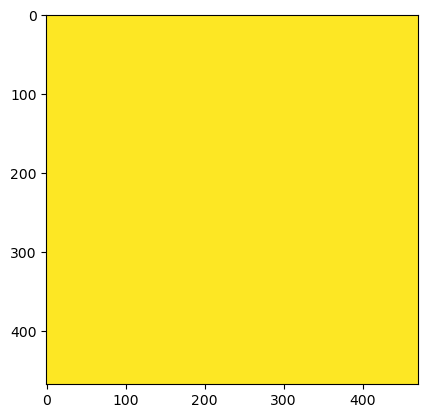

<AxesSubplot:>

In [60]:
from rasterio.plot import show
show(test.sel(orbit = 'Descending').where(~test['angle_desc'].isnull(), drop=True).isel(time=0)['angle_desc'].data, vmin=34, vmax=42)

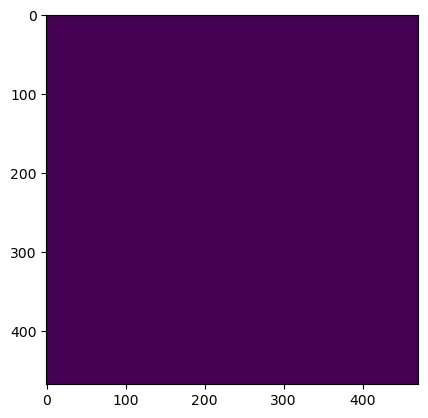

<AxesSubplot:>

In [63]:
show(test.sel(orbit = 'Descending').where(~test['angle_desc'].isnull(), drop=True).isel(time=3)['angle_desc'].data, vmin=34, vmax=42)

In [32]:
s1_ds.sel(orbit = 'Descending').where(~s1_ds['VH_sig_desc'].isnull(), drop=True)['time']

<xarray.DataArray 'time' (time: 78)>
array(['2022-11-03T13:01:35.000000000', '2022-11-08T13:09:31.000000000',
       '2022-11-15T13:01:35.000000000', '2022-11-20T13:09:31.000000000',
       '2022-11-27T13:01:35.000000000', '2022-12-02T13:09:31.000000000',
       '2022-12-09T13:01:34.000000000', '2022-12-14T13:09:30.000000000',
       '2022-12-21T13:01:33.000000000', '2023-01-02T13:01:33.000000000',
       '2023-01-07T13:09:29.000000000', '2023-01-14T13:01:32.000000000',
       '2023-01-19T13:09:28.000000000', '2023-01-26T13:01:32.000000000',
       '2023-02-07T13:01:31.000000000', '2023-02-12T13:09:28.000000000',
       '2023-02-19T13:01:31.000000000', '2023-02-24T13:09:27.000000000',
       '2023-03-03T13:01:31.000000000', '2023-03-08T13:09:27.000000000',
       '2023-03-15T13:01:31.000000000', '2023-03-20T13:09:27.000000000',
       '2023-03-27T13:01:32.000000000', '2023-04-01T13:09:28.000000000',
       '2023-04-08T13:01:32.000000000', '2023-04-13T13:09:28.000000000',
       '2023-04-20T13:01:32.000000000', '2023-04-25T13:09:28.000000000',
       '2023-05-02T13:01:33.000000000', '2023-05-07T13:09:29.000000000',
       '2023-05-14T13:01:33.000000000', '2023-05-19T13:09:30.000000000',
       '2023-05-26T13:01:34.000000000', '2023-05-31T13:09:30.000000000',
       '2023-06-07T13:01:34.000000000', '2023-06-12T13:09:31.000000000',
       '2023-06-19T13:01:35.000000000', '2023-06-24T13:09:32.000000000',
       '2023-07-01T13:01:36.000000000', '2023-07-06T13:09:32.000000000',
       '2023-07-13T13:01:37.000000000', '2023-07-18T13:09:33.000000000',
       '2023-07-25T13:01:37.000000000', '2023-07-30T13:09:34.000000000',
       '2023-08-06T13:01:38.000000000', '2023-08-11T13:09:34.000000000',
       '2023-08-18T13:01:39.000000000', '2023-08-23T13:09:35.000000000',
       '2023-08-30T13:01:39.000000000', '2023-09-04T13:09:36.000000000',
       '2023-09-11T13:01:40.000000000', '2023-09-16T13:09:36.000000000',
       '2023-09-23T13:01:40.000000000', '2023-09-28T13:09:37.000000000',
       '2023-10-05T13:01:40.000000000', '2023-10-10T13:09:36.000000000',
       '2023-10-17T13:01:41.000000000', '2023-10-22T13:09:37.000000000',
       '2023-11-03T13:09:36.000000000', '2023-11-10T13:01:40.000000000',
       '2023-11-15T13:09:36.000000000', '2023-11-22T13:01:40.000000000',
       '2023-11-27T13:09:35.000000000', '2023-12-04T13:01:39.000000000',
       '2023-12-09T13:09:35.000000000', '2023-12-16T13:01:39.000000000',
       '2023-12-21T13:09:34.000000000', '2023-12-28T13:01:38.000000000',
       '2024-01-02T13:09:34.000000000', '2024-01-09T13:01:37.000000000',
       '2024-01-14T13:09:33.000000000', '2024-01-21T13:01:37.000000000',
       '2024-01-26T13:09:33.000000000', '2024-02-02T13:01:36.000000000',
       '2024-02-07T13:09:32.000000000', '2024-02-14T13:01:36.000000000',
       '2024-02-19T13:09:32.000000000', '2024-02-26T13:01:36.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2022-11-03T13:01:35 ... 2024-02-26T13:01:36
    orbit    <U10 'Descending'

In [71]:
yr = 2019
# get subset of vor data for year
gdf_yr = gdf_vor[gdf_vor['Year'] == yr]
# set the bounding box for fetching data
bbox_yr = np.array(gdf_yr.total_bounds) # the entire subset dataset 


# get the date range for the fetch as a dictionary
#start_date = gdf_yr['Date'].min().date() - timedelta(days=30)
#end_date = gdf_yr['Date'].max().date() + timedelta(days=30)
start_date = str(yr - 1) + "-11-01"
end_date = str(yr + 1) + "-03-01"
datestr = "/".join([start_date, end_date])

s1_ds = gets1(bbox_yr, [start_date, end_date])#.load()

In [72]:
s1_ds

<xarray.Dataset>
Dimensions:             (time: 118, orbit: 2, y: 468, x: 471)
Coordinates:
  * time                (time) datetime64[ns] 2018-11-01T00:53:43 ... 2020-02...
  * orbit               (orbit) <U10 'Ascending' 'Descending'
  * x                   (x) float64 5.177e+05 5.178e+05 ... 5.271e+05 5.271e+05
  * y                   (y) float64 4.524e+06 4.524e+06 ... 4.515e+06 4.515e+06
Data variables: (12/21)
    VH_sig_asc          (time, y, x) float32 0.001244 9.923e-05 ... nan nan
    VV_sig_asc          (time, y, x) float32 0.01437 0.01509 ... nan nan
    VHVV_sum_asc        (time, y, x) float32 0.01561 0.01519 0.01007 ... nan nan
    VHVV_diff_asc       (time, y, x) float32 -0.01312 -0.01499 ... nan nan
    VHVV_ratio_asc      (time, y, x) float32 0.08656 0.006575 ... nan nan
    RVI_asc             (time, y, x) float32 0.3186 0.02613 0.05342 ... nan nan
    ...                  ...
    VV_sig_desc_lo      (time, y, x) float32 nan nan nan ... 0.03135 0.02939
    VHVV_sum_desc_lo    (time, y, x) float32 nan nan nan ... 0.03465 0.03125
    VHVV_diff_desc_lo   (time, y, x) float32 nan nan nan ... -0.02805 -0.02754
    VHVV_ratio_desc_lo  (time, y, x) float32 nan nan nan ... 0.1052 0.06306
    RVI_desc_lo         (time, y, x) float32 nan nan nan ... 0.401 0.3807 0.2373
    angle_desc_lo       (time, y, x) float32 nan nan nan ... 31.48 31.47 31.47
Attributes:
    crs:      EPSG:32613

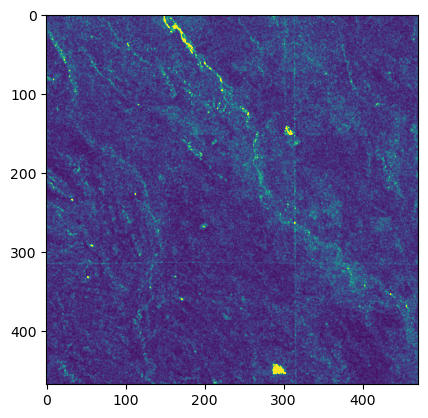

<AxesSubplot:>

In [49]:
from rasterio.plot import show
show(s1_ds.isel(time=100)['VHVV_sum'].data, vmin=0, vmax=0.1)

In [55]:
# fetch the data for the entire year's dataset
s2_ds = gets2(bbox_yr, [start_date, end_date]).load()
s2_ds = s2_ds.rename_vars({k:s2_band_dict[k] for k in load_bands})

# drop pixels with negative values for blue band
s2_ds = s2_ds.where(s2_ds['BLUE'] > 0)

In [61]:
ds_comb = xr.combine_by_coords([s2_ds, s1_ds])

In [ ]:
if mask_bolton_by_pixel:
    # compute the bolton mask
    s2_bolton_mask = bolton_mask(s2_ds).compute()
    #s2_ds = xr.merge([s2_ds, s2_atsa], join='inner')
    s2_ds.where(s2_ds['BOLTON'] == 0, drop=True)

# compute native S2 mask, including all aerosol flags
#s2_ds = s2_ds.where(s2_ds['SCL'].isin(scl_goodvals))

# create an xarray mask from the ground data
mask_info = gdf_vor.drop_duplicates(subset=['Id', 'Date'])[['Id', 'geometry']].reset_index(drop=True).reset_index().rename(columns={'index': 'id'})
mask_shp = [(row.geometry, row.id+1) for _, row in mask_info.iterrows()]
plot_mask = shp2mask(shp=mask_shp, 
                     transform=s2_ds.rio.transform(), 
                     outshape=s2_ds['BLUE'].shape[1:], 
                     xr_object=s2_ds['BLUE'])
mask_dict = {row.id+1: row.Id for _, row in mask_info.iterrows()}
mask_dict[0] = 'UNK'
plot_mask = np.array([mask_dict[i] for i in plot_mask.values.flatten()]).reshape(plot_mask.shape)

# assign the plot id's to the xarray dataset
ds_comb = ds_comb.assign(Plot=(['y', 'x'], plot_mask)).chunk({'y': 50, 'x': 50})
ds_comb = ds_comb.set_coords('Plot')

# mask out areas outside ground plots
ds_comb = ds_comb.where(ds_comb['Plot'] != 'UNK')

# create variable to get percentage of pixels that are NA for a given date
ds_comb['NA_pct'] = ds_comb['BLUE'].isnull().astype('int') * 1.0

# lazy compute all vegetation indices
for vegidx in veg_dict:
    ds_comb[vegidx] = veg_dict[vegidx](ds_comb)

# convert to dataframe at plot scale, if any pixels are NA, result is NA with skipna=False
df_yr = ds_comb[all_vis + band_list + gee_s1_vis + ['NA_pct']].groupby('Plot').mean('stacked_y_x', skipna=True).to_dataframe().reset_index()

# remove all non-plot data
df_yr = df_yr[df_yr['Plot'] != 'UNK']

# remove any dates where bands are negative
#df_yr = df_yr[~((df_yr[band_list] < 0).any(axis=1))]

# rename columns to match VOR data
df_yr = df_yr.rename(columns={'time': 'Date',
                                'Plot': 'Id'})
# convert date to datetime
df_yr['Date'] = pd.to_datetime(df_yr['Date'].dt.date)

# get missing dates for gap-filling
dates_missing = [x for x in pd.date_range(start_date, end_date).date if x not in df_yr['Date'].dt.date.unique()]

# convert missing dates to a dataframe for combining with veg index data
df_missing = pd.DataFrame({
    'Id': list(chain.from_iterable([list(np.repeat(x, len(dates_missing))) for x in df_yr['Id'].unique()])),
    'Date': list(chain.from_iterable(dates_missing for x in df_yr['Id'].unique()))})

# combine into one dataframe for gapfilling
df_yr_ts = pd.concat([df_yr, df_missing]).sort_values(['Id', 'Date'])

# apply Bolton mask to extracted values
if mask_bolton_by_id:
    ps_bolton = df_yr_ts.groupby('Id').progress_apply(lambda x: bolton_mask_np(x['BLUE'], x['SWIR2']))
    df_yr_ts.loc[df_yr_ts[ps_bolton.droplevel(0) == 1.0].index, all_vis + band_list] = np.nan

# smooth all vegetation indices to gapfill
for vegidx in all_vis:
    #df_yr_ts[vegidx + '_smooth'] = df_yr_ts.groupby('Id')[vegidx].transform(lambda x: double_savgol(x.values))
    vals_smooth_yr = df_yr_ts.groupby('Id').apply(lambda x: adapt_smooth(x[vegidx], pd.to_datetime(x['Date'])))
    df_yr_ts[vegidx + '_smooth'] = vals_smooth_yr.droplevel(list(np.arange(vals_smooth_yr.index.nlevels-1)))
for band in band_list:
    #df_yr_ts[band + '_smooth'] = df_yr_ts.groupby('Id')[band].transform(lambda x: double_savgol(x.values))
    vals_smooth_yr = df_yr_ts.groupby('Id').apply(lambda x: adapt_smooth(x[band], pd.to_datetime(x['Date'])))
    df_yr_ts[band + '_smooth'] = vals_smooth_yr.droplevel(list(np.arange(vals_smooth_yr.index.nlevels-1)))
for s1idx in gee_s1_vis:
    #df_yr_ts[vegidx + '_smooth'] = df_yr_ts.groupby('Id')[vegidx].transform(lambda x: double_savgol(x.values))
    vals_smooth_yr = df_yr_ts.groupby('Id').apply(lambda x: adapt_smooth(x[s1idx], pd.to_datetime(x['Date'])))
    df_yr_ts[s1idx + '_smooth'] = vals_smooth_yr.droplevel(list(np.arange(vals_smooth_yr.index.nlevels-1)))

# convert date to datetime
df_yr_ts['Date'] = pd.to_datetime(df_yr_ts['Date'])

if save_raw:
    if df_out_raw is not None:
        # merge with existing output dataset
        df_out_raw = pd.concat([df_out_raw, df_yr_ts])
    else:
        df_out_raw = df_yr_ts.copy()
    df_out_raw.to_csv(outPATH_raw, index=False)

# rename smoothed columns and drop originals
df_yr_ts = df_yr_ts.drop(columns=list(all_vis + band_list + gee_s1_vis))
col_rename_dict = {c: re.sub('_smooth', '', c) for c in df_yr_ts.columns if '_smooth' in c}
df_yr_ts = df_yr_ts.rename(columns=col_rename_dict)

df_out_yr = pd.merge(gdf_yr, 
                     df_yr_ts[['Id', 'Date'] + all_vis + band_list + gee_s1_vis], 
                     on=['Id', 'Date'],
                     how='left')

In [75]:
df_out_yr

,Id,Pasture,Date,Date_mean,Year,Season,Low,High,Biomass_kg_ha,geometry,...,NIR1,SWIR1,SWIR2,VH_sig,VV_sig,VHVV_sum,VHVV_diff,VHVV_ratio,RVI,angle
0,5W_P1_3,5W,2019-06-04,2019-06-04,2019,June,2.88,11.19,664.368731,"POLYGON ((525795.642 4522941.695, 525795.570 4...",...,3222.490479,3987.264404,3199.729492,0.010273,0.074384,0.084657,-0.064111,0.119162,0.428565,36.536442
1,5W_P2_1,5W,2019-06-04,2019-06-04,2019,June,1.19,5.94,305.813098,"POLYGON ((526052.727 4522840.522, 526052.654 4...",...,3545.718506,4401.897949,3634.441895,0.004592,0.057054,0.061646,-0.052461,0.089274,0.320369,36.525768
2,5W_P2_2,5W,2019-06-04,2019-06-04,2019,June,1.00,6.31,278.383326,"POLYGON ((526158.776 4522840.522, 526158.704 4...",...,3506.784912,4299.139160,3522.204346,0.004516,0.076103,0.080619,-0.071586,0.060414,0.219946,36.521748
3,5W_P2_3,5W,2019-06-04,2019-06-04,2019,June,2.20,8.60,513.453525,"POLYGON ((526052.727 4522944.522, 526052.654 4...",...,3187.056885,3996.598145,3290.339355,0.009566,0.063958,0.073524,-0.054392,0.155446,0.520053,36.526917
4,5W_P3_2,5W,2019-06-04,2019-06-04,2019,June,2.44,9.12,560.412567,"POLYGON ((526354.518 4523000.319, 526354.446 4...",...,3439.742920,4113.566406,3344.672607,0.007932,0.069277,0.077209,-0.061344,0.108039,0.386662,36.515953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1059,8E_P1_4,8E,2019-10-15,2019-10-15,2019,October,3.79,23.86,999.831513,"POLYGON ((526650.416 4521556.503, 526650.343 4...",...,1927.702759,3012.175293,2390.453369,0.002186,0.022513,0.024699,-0.020327,0.111072,0.386465,36.792152
1060,8E_P1_3,8E,2019-10-15,2019-10-15,2019,October,2.25,19.31,670.004763,"POLYGON ((526544.365 4521556.503, 526544.293 4...",...,1972.907715,3274.127930,2650.477051,0.001922,0.015476,0.017398,-0.013554,0.143105,0.440177,36.795837
1061,8E_P1_2,8E,2019-10-15,2019-10-15,2019,October,3.07,22.43,855.961789,"POLYGON ((526650.416 4521452.503, 526650.343 4...",...,1848.566528,2871.267822,2258.634277,0.001776,0.019310,0.021086,-0.017535,0.099183,0.346642,36.790997
1062,8E_P1_1,8E,2019-10-15,2019-10-15,2019,October,1.75,12.44,493.172265,"POLYGON ((526544.365 4521452.503, 526544.293 4...",...,1905.932495,3164.462402,2516.842529,0.001611,0.017365,0.018977,-0.015754,0.098675,0.338911,36.794659


In [81]:
df_out_raw.columns

Index(['Id', 'Date', 'DFI', 'NDTI', 'SATVI', 'NDII7', 'RDVI', 'MTVI1', 'NCI',
       'NDVI', 'mARI', 'CHL-RED-EDGE', 'EVI', 'MCARI', 'MSI', 'NDMI', 'NDWI',
       'NDMI_MoistureStress', 'NDCI', 'PSSRb1', 'SAVI', 'SIPI', 'PSRI', 'BLUE',
       'GREEN', 'RED', 'RED-EDGE1', 'RED-EDGE2', 'RED-EDGE3', 'NIR-Broad',
       'NIR1', 'SWIR1', 'SWIR2', 'NA_pct', 'DFI_smooth', 'NDTI_smooth',
       'SATVI_smooth', 'NDII7_smooth', 'RDVI_smooth', 'MTVI1_smooth',
       'NCI_smooth', 'NDVI_smooth', 'mARI_smooth', 'CHL-RED-EDGE_smooth',
       'EVI_smooth', 'MCARI_smooth', 'MSI_smooth', 'NDMI_smooth',
       'NDWI_smooth', 'NDMI_MoistureStress_smooth', 'NDCI_smooth',
       'PSSRb1_smooth', 'SAVI_smooth', 'SIPI_smooth', 'PSRI_smooth',
       'BLUE_smooth', 'GREEN_smooth', 'RED_smooth', 'RED-EDGE1_smooth',
       'RED-EDGE2_smooth', 'RED-EDGE3_smooth', 'NIR-Broad_smooth',
       'NIR1_smooth', 'SWIR1_smooth', 'SWIR2_smooth', 'VH_sig', 'VV_sig',
       'VHVV_sum', 'VHVV_diff', 'VHVV_ratio', 'RVI', 'angl

<AxesSubplot:xlabel='Date', ylabel='RVI_smooth'>

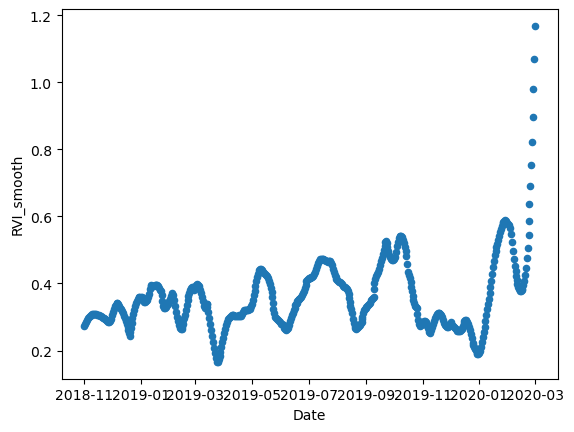

In [90]:
id = df_out_raw['Id'].unique()[0]
df_out_raw[df_out_raw['Id'] == id].sort_values('Date').plot(x='Date', y='RVI_smooth', kind='scatter')

In [32]:
# convert to dataframe at plot scale, if any pixels are NA, result is NA with skipna=False
df_yr = s2_ds[all_vis + band_list + ['NA_pct']].groupby('Plot').mean('stacked_y_x', skipna=True).to_dataframe().reset_index()

# remove all non-plot data
df_yr = df_yr[df_yr['Plot'] != 'UNK']

# remove any dates where bands are negative
#df_yr = df_yr[~((df_yr[band_list] < 0).any(axis=1))]

# rename columns to match VOR data
df_yr = df_yr.rename(columns={'time': 'Date',
                                'Plot': 'Id'})
# convert date to datetime
df_yr['Date'] = pd.to_datetime(df_yr['Date'].dt.date)

# get missing dates for gap-filling
dates_missing = [x for x in pd.date_range(start_date, end_date).date if x not in df_yr['Date'].dt.date.unique()]

# convert missing dates to a dataframe for combining with veg index data
df_missing = pd.DataFrame({
    'Id': list(chain.from_iterable([list(np.repeat(x, len(dates_missing))) for x in df_yr['Id'].unique()])),
    'Date': list(chain.from_iterable(dates_missing for x in df_yr['Id'].unique()))})

# combine into one dataframe for gapfilling
df_yr_ts = pd.concat([df_yr, df_missing]).sort_values(['Id', 'Date'])

# apply Bolton mask to extracted values
if mask_bolton_by_id:
    ps_bolton = df_yr_ts.groupby('Id').progress_apply(lambda x: bolton_mask_np(x['BLUE'], x['SWIR2']))
    df_yr_ts.loc[df_yr_ts[ps_bolton.droplevel(0) == 1.0].index, all_vis + band_list] = np.nan

# smooth all vegetation indices to gapfill
for vegidx in all_vis:
    #df_yr_ts[vegidx + '_smooth'] = df_yr_ts.groupby('Id')[vegidx].transform(lambda x: double_savgol(x.values))
    vals_smooth_yr = df_yr_ts.groupby('Id').apply(lambda x: adapt_smooth(x[vegidx], pd.to_datetime(x['Date'])))
    df_yr_ts[vegidx + '_smooth'] = vals_smooth_yr.droplevel(list(np.arange(vals_smooth_yr.index.nlevels-1)))
for band in band_list:
    #df_yr_ts[band + '_smooth'] = df_yr_ts.groupby('Id')[band].transform(lambda x: double_savgol(x.values))
    vals_smooth_yr = df_yr_ts.groupby('Id').apply(lambda x: adapt_smooth(x[band], pd.to_datetime(x['Date'])))
    df_yr_ts[band + '_smooth'] = vals_smooth_yr.droplevel(list(np.arange(vals_smooth_yr.index.nlevels-1)))

# convert date to datetime
df_yr_ts['Date'] = pd.to_datetime(df_yr_ts['Date'])

if save_raw:
    if df_out_raw is not None:
        # merge with existing output dataset
        df_out_raw = pd.concat([df_out_raw, df_yr_ts])
    else:
        df_out_raw = df_yr_ts.copy()
    df_out_raw.to_csv(outPATH_raw, index=False)

# rename smoothed columns and drop originals
df_yr_ts = df_yr_ts.drop(columns=list(all_vis + band_list))
col_rename_dict = {c: re.sub('_smooth', '', c) for c in df_yr_ts.columns if '_smooth' in c}
df_yr_ts = df_yr_ts.rename(columns=col_rename_dict)

df_out_yr = pd.merge(gdf_yr, 
                     df_yr_ts[['Id', 'Date'] + all_vis + band_list], 
                     on=['Id', 'Date'],
                     how='left')

if df_out is not None:
    # merge with existing ouptput dataset
    df_out = pd.concat([df_out, df_out_yr])
else:
    # create output dataset
    df_out = df_out_yr.copy()
df_out.to_csv(outPATH, index=False)
time.sleep(2)
del df_yr, df_yr_ts, df_out_yr, gdf_yr
del s2_ds
if mask_bolton_by_pixel:
    del s2_bolton_mask
if mask_bolton_by_id:
    del ps_bolton
gc.collect()
client.restart(timeout=300)
time.sleep(5)

NameError: name 's2_ds' is not defined

In [21]:
yr = 2019
# get subset of vor data for year
gdf_yr = gdf_vor[gdf_vor['Year'] == yr]
# set the bounding box for fetching data
bbox_yr = np.array(gdf_yr.total_bounds) # the entire subset dataset 

# get the date range for the fetch as a dictionary
#start_date = gdf_yr['Date'].min().date() - timedelta(days=30)
#end_date = gdf_yr['Date'].max().date() + timedelta(days=30)
start_date = str(yr - 1) + "-11-01"
end_date = str(yr + 1) + "-03-01"
datestr = "/".join([start_date, end_date])

# fetch the data for the entire year's dataset
s2_ds = gets2(bbox_yr, [start_date, end_date]).load()

In [54]:
s2_ds

NameError: name 's2_ds' is not defined

In [25]:
s2_ds = s2_ds.rename_vars({k:s2_band_dict[k] for k in load_bands})

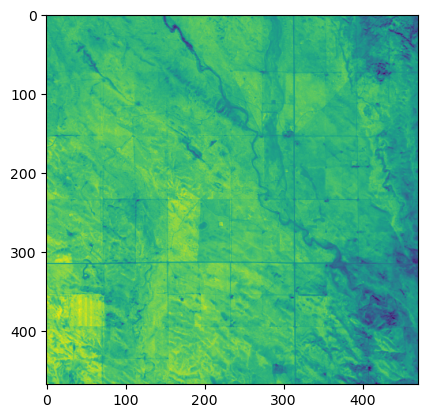

<AxesSubplot:>

In [39]:
from rasterio.plot import show
show(s2_ds.isel(time=121)['MSI'].data)

In [54]:
# convert date to datetime
df_yr_ts['Date'] = pd.to_datetime(df_yr_ts['Date'])

if save_raw:
    if df_out_raw is not None:
        # merge with existing output dataset
        df_out_raw = pd.concat([df_out_raw, df_yr_ts])
    else:
        df_out_raw = df_yr_ts.copy()
    df_out_raw.to_csv(outPATH_raw, index=False)

# rename smoothed columns and drop originals
df_yr_ts = df_yr_ts.drop(columns=list(veg_dict.keys()) + band_list)
col_rename_dict = {c: re.sub('_smooth', '', c) for c in df_yr_ts.columns if '_smooth' in c}
df_yr_ts = df_yr_ts.rename(columns=col_rename_dict)

df_out_yr = pd.merge(gdf_yr, 
                     df_yr_ts[['Id', 'Date'] + list(veg_dict.keys()) + band_list], 
                     on=['Id', 'Date'],
                     how='left')

if df_out is not None:
    # merge with existing ouptput dataset
    df_out = pd.concat([df_out, df_out_yr])
else:
    # create output dataset
    df_out = df_out_yr.copy()
df_out.to_csv(outPATH, index=False)
time.sleep(2)
del df_yr, df_yr_ts, df_out_yr, gdf_yr
del s2_ds
if mask_bolton_by_pixel:
    del s2_bolton_mask
if mask_bolton_by_id:
    del ps_bolton
gc.collect()
client.restart(timeout=300)
time.sleep(5)

2025-08-06 17:27:32,525 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:32,652 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:32,655 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:32,702 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:32,744 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:32,788 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:32,847 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:32,896 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:32,955 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:33,005 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:33,064 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:33,114 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:33,155 - distributed.nanny - WARNING - Restarting worker
2025-08-06 17:27:33,214 - distributed.

In [84]:
# manually re-save output data if needbe
df_raw = pd.read_csv(outPATH_raw, parse_dates=['Date'])

#df_out = pd.read_csv(outPATH, parse_dates=['Date'])

df_raw['Date'] = pd.to_datetime(df_raw['Date'].dt.date)
#df_out['Date'] = pd.to_datetime(df_out['Date'].dt.date)

df_out = pd.merge(gdf_vor, 
                df_raw[['Id', 'Date'] + [x + '_smooth' for x in list(veg_dict.keys()) + band_list]], 
                on=['Id', 'Date'],
                how='left')

col_rename_dict = {c: re.sub('_smooth', '', c) for c in df_out.columns if '_smooth' in c}
df_out = df_out.rename(columns=col_rename_dict)

df_out.to_csv(outPATH, index=False)

In [77]:
#df_out_raw[(df_out_raw['Id'] == ID)][['Date', 'NIR1_smooth']].isnull().any()

In [78]:
#df_raw['Date'].dt.date

In [81]:
test[~test['Date'].isin(df_raw['Date'])]['Date'].unique()

array([], dtype='datetime64[ns]')

<AxesSubplot:xlabel='Date', ylabel='NIR1_smooth'>

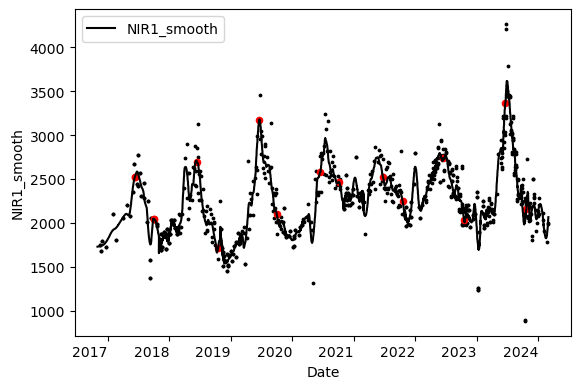

In [80]:
ID = '15E_P1_1'
var = 'NIR1'
ax1 = df_out_raw[(df_out_raw['Id'] == ID)].plot(x='Date', y=var + '_smooth', c='black')
df_out_raw[(df_out_raw['Id'] == ID)].plot.scatter(x='Date', y=var, c='black', ax=ax1, s=3)
test[(test['Id'] == ID)].plot.scatter(x='Date', y=var + '_smooth', c='red', ax=ax1)

<AxesSubplot:xlabel='Date', ylabel='NIR1'>

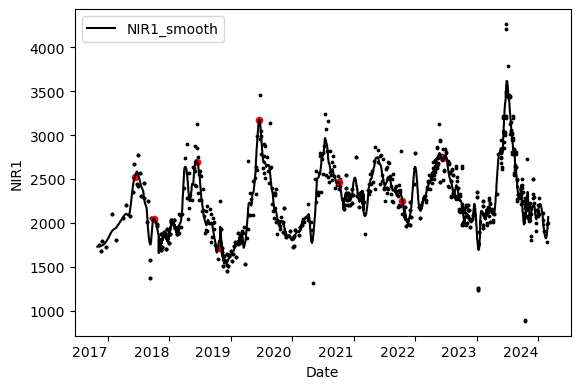

In [48]:
ID = '15E_P1_1'
var = 'NIR1'
ax1 = df_out_raw[(df_out_raw['Id'] == ID)].plot(x='Date', y=var + '_smooth', c='black')
df_out_raw[(df_out_raw['Id'] == ID)].plot.scatter(x='Date', y=var, c='black', ax=ax1, s=3)
df_out[(df_out['Id'] == ID)].plot.scatter(x='Date', y=var, c='red', ax=ax1)

In [49]:
df_out[(df_out['Id'] == ID)]

,Id,Pasture,Date,Date_mean,Year,Season,Low,High,Biomass_kg_ha,geometry,...,BLUE,GREEN,RED,RED-EDGE1,RED-EDGE2,RED-EDGE3,NIR-Broad,NIR1,SWIR1,SWIR2
328,15E_P1_1,15E,2017-06-12,2017-06-12,2017,June,3.81,15.94,888.861926,"POLYGON ((520196.4702758789 4520636.452514648,...",...,787.885433,1064.235924,1133.418678,1519.839296,2161.243194,2346.544774,2365.288601,2530.778888,3489.446003,2580.086892
628,15E_P1_1,15E,2017-10-03,2017-10-03,2017,October,1.75,15.44,531.139784,"POLYGON ((520196.4702758789 4520636.452514648,...",...,753.001510,981.740065,1234.060693,1505.318762,1712.062579,1838.995779,1919.542724,2042.519386,3387.646578,2671.779622
1345,15E_P1_1,15E,2018-06-15,2018-06-16,2018,June,3.62,16.00,859.044748,"POLYGON ((520196.4702758789 4520636.452514648,...",...,857.994201,1140.675892,1334.234255,1736.868000,2238.443000,2439.316605,2527.914821,2691.950084,3571.063585,2670.532866
1762,15E_P1_1,15E,2018-10-18,2018-10-18,2018,October,2.12,10.31,526.832021,"POLYGON ((520196.4702758789 4520636.452514648,...",...,774.791038,952.209505,1215.093071,1342.088075,1414.613420,1522.536953,1650.294674,1716.745806,3415.367080,2874.844734
2200,15E_P1_1,15E,2019-06-19,2019-06-19,2019,June,4.06,16.25,933.862430,"POLYGON ((520196.4702758789 4520636.452514648,...",...,850.336035,1170.232187,1204.179049,1724.652504,2617.769006,2906.648379,3014.031367,3169.958518,3584.320655,2664.701074
2533,15E_P1_1,15E,2019-10-01,2019-10-01,2019,October,3.50,22.94,937.613826,"POLYGON ((520196.4702758789 4520636.452514648,...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3293,15E_P1_1,15E,2020-06-15,2020-06-13,2020,June,1.75,13.75,510.084250,"POLYGON ((520196.4702758789 4520636.452514648,...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3621,15E_P1_1,15E,2020-10-07,2020-10-07,2020,October,1.19,6.38,312.313103,"POLYGON ((520196.4702758789 4520636.452514648,...",...,1142.822445,1394.467913,1786.666956,1980.296857,2078.165699,2207.196200,2347.397304,2464.669584,3997.980094,3312.097356
4336,15E_P1_1,15E,2021-06-22,2021-06-21,2021,June,3.38,22.81,915.115432,"POLYGON ((520196.4702758789 4520636.452514648,...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4764,15E_P1_1,15E,2021-10-18,2021-10-18,2021,October,2.06,31.00,764.444922,"POLYGON ((520196.4702758789 4520636.452514648,...",...,831.451095,1103.574914,1459.106704,1679.670658,1822.334762,1973.683245,2131.763395,2251.088197,3331.326435,2458.458151


<AxesSubplot:xlabel='Date', ylabel='NIR1'>

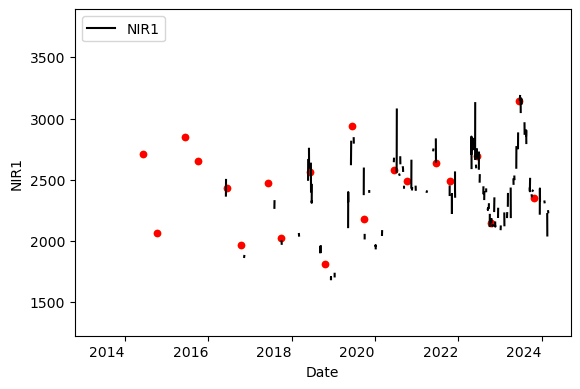

In [19]:
ID = '15E_P1'
var = 'NIR1'
ax1 = df_out_raw[(df_out_raw['Id'] == ID)].plot(x='Date', y=var, c='black')
df_out[(df_out['Id'] == ID)].plot.scatter(x='Date', y=var, c='orange', ax=ax1)
df_out[(df_out['Id'] == ID)].plot.scatter(x='Date', y=var, c='red', ax=ax1)

#### Manually merge HLS and LMF datasets

In [9]:
df_out_old = pd.read_csv(re.sub('.csv', '_old.csv', outPATH), parse_dates=['Date'])

In [14]:
df_out_manual = pd.concat([df_out[df_out['Year'] < lmf_yr_max], 
                           df_out_old[df_out_old['Year'] >= lmf_yr_max]])


In [15]:
df_out_manual['Year'].unique()

array([2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [16]:
df_out_manual.to_csv(re.sub('.csv', '_manual_combine.csv', outPATH), index=False)

### OTHER TESTING (TEMP)

In [17]:
yr = 2015
# get subset of vor data for year
gdf_yr = gdf_vor[gdf_vor['Year'] == yr]
# set the bounding box for fetching data
bbox_yr = np.array(gdf_yr.total_bounds) # the entire subset dataset 
lmfPATH_yr = glob(os.path.join(lmfDIR, 'CPER_' + str(yr) + '*.nc'))
lmf_ds = riox.open_rasterio(lmfPATH_yr[0], 
              nodata=-9999, mask=True).sel(x=slice(bbox_yr[0], bbox_yr[2]),
                                           y=slice(bbox_yr[3], bbox_yr[1])).load()
lmf_ds = lmf_ds.chunk({'DOY': -1, 'y': 50, 'x': 50})

# create an xarray mask from the ground data
mask_info = gdf_vor.drop_duplicates(
    subset=['Id', 'Date'])[['Id', 'geometry']].reset_index(drop=True).reset_index().rename(
    columns={'index': 'id'})
mask_shp = [(row.geometry, row.id+1) for _, row in mask_info.iterrows()]
plot_mask = shp2mask(shp=mask_shp, 
                     transform=lmf_ds.rio.transform(), 
                     outshape=lmf_ds['BLUE'].shape[1:], 
                     xr_object=lmf_ds['BLUE'])
mask_dict = {row.id+1: row.Id for _, row in mask_info.iterrows()}
mask_dict[0] = 'UNK'
plot_mask = np.array([mask_dict[i] for i in plot_mask.values.flatten()]).reshape(plot_mask.shape)

# assign the plot id's to the xarray dataset
lmf_ds = lmf_ds.assign(Plot=(['y', 'x'], plot_mask)).chunk({'y': 50, 'x': 50})
lmf_ds = lmf_ds.set_coords('Plot')

# mask out areas outside ground plots
lmf_ds = lmf_ds.where(lmf_ds['Plot'] != 'UNK')

# lazy compute all vegetation indices
for vegidx in veg_dict:
    lmf_ds[vegidx] = veg_dict[vegidx](lmf_ds)

# convert to dataframe at plot scale
df_yr = lmf_ds[list(veg_dict.keys()) + band_list].groupby('Plot').mean('stacked_y_x').to_dataframe().reset_index()

df_yr['time'] = df_yr['DOY'].apply(lambda x: datetime(yr, 1, 1) + timedelta(days=x))
df_yr = df_yr.drop(columns=['DOY'])

start_date = df_yr['time'].min()
end_date = df_yr['time'].max()

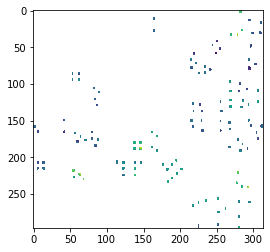

<AxesSubplot:>

In [18]:
from rasterio.plot import show
#(lmf_ds['SWIR1'].isel(DOY=278)/1000).values
show((lmf_ds['SWIR1'].isel(DOY=278)/1000).values)

In [41]:
df_yr[(df_yr['Plot'] == '25NW_P1') & (df_yr['time'] == '2013-10-06')]

,Plot,NDVI,DFI,NDTI,SATVI,NDII7,BAI_126,BAI_136,BAI_146,BAI_236,BAI_246,BAI_346,NIR1,SWIR1,SWIR2,spatial_ref,time
24367,25NW_P1,0.347822,11.6628,0.137122,0.218866,-0.030899,150.035533,159.821334,134.111776,170.917063,133.072568,125.956071,2387.172414,3347.344828,2540.793103,0,2013-10-06


In [19]:
test = lmf_ds['SWIR1'].sel(DOY=278).groupby('Plot').mean('stacked_y_x').to_dataframe().reset_index()
test[['25NW' in x for x in test['Plot']]]

,Plot,DOY,spatial_ref,SWIR1
66,25NW_P1,278.0,0,3515.000000
67,25NW_P2,278.0,0,3471.689655
68,25NW_P3,278.0,0,3443.482759
69,25NW_P4,278.0,0,3328.379310


In [51]:
# remove any dates where bands are nodata (-9999)
df_yr = df_yr[~(df_yr[band_list] < 0).any(axis=1)]

In [52]:
df_yr[(df_yr['Plot'] == ID)][var].min()

1007.56

<AxesSubplot:xlabel='Date', ylabel='NIR1'>

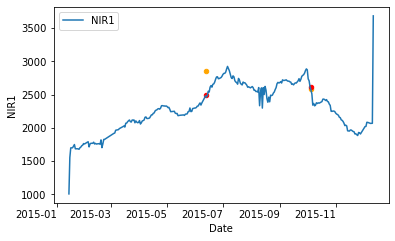

In [53]:
ID = '15E_P1'
var = 'NIR1'
ax1 = df_yr[(df_yr['Plot'] == ID)].plot(x='time', y=var)
df_out_old[(df_out_old['Id'] == ID) & 
           (df_out_old['Year'] == 2015)].plot.scatter(x='Date', y=var, c='orange', ax=ax1)
df_out[(df_out['Id'] == ID) & 
           (df_out['Year'] == 2015)].plot.scatter(x='Date', y=var, c='red', ax=ax1)

In [54]:
# remove all non-plot data
df_yr = df_yr[df_yr['Plot'] != 'UNK']

# rename columns to match VOR data
df_yr = df_yr.rename(columns={'time': 'Date',
                                'Plot': 'Id'})

In [55]:
# remove any dates where bands are nodata (-9999)
df_yr = df_yr[~(df_yr[band_list] < 0).any(axis=1)]

# get missing dates for gap-filling
dates_missing = [x for x in pd.date_range(start_date, end_date).date if x not in df_yr['Date'].dt.date.unique()]

# convert missing dates to a dataframe for combining with veg index data
df_missing = pd.DataFrame({
    'Id': list(chain.from_iterable([list(np.repeat(x, len(dates_missing))) for x in df_yr['Id'].unique()])),
    'Date': list(chain.from_iterable(dates_missing for x in df_yr['Id'].unique()))})

# combine into one dataframe for gapfilling
df_yr_ts = pd.concat([df_yr, df_missing]).sort_values(['Id', 'Date'])

# smooth all vegetation indices to gapfill
for vegidx in veg_dict:
    df_yr_ts[vegidx + '_smooth'] = df_yr_ts.groupby('Id')[vegidx].transform(lambda x: double_savgol(x.values))
for band in band_list:
    df_yr_ts[band + '_smooth'] = df_yr_ts.groupby('Id')[band].transform(lambda x: double_savgol(x.values))

# convert date to datetime
df_yr_ts['Date'] = pd.to_datetime(df_yr_ts['Date'])

# rename smoothed columns and drop originals
df_yr_ts = df_yr_ts.drop(columns=list(veg_dict.keys()) + band_list)
col_rename_dict = {c: re.sub('_smooth', '', c) for c in df_yr_ts.columns if '_smooth' in c}
df_yr_ts = df_yr_ts.rename(columns=col_rename_dict)

/home/spkearney/miniconda3/envs/hls_nrt_env/lib/python3.10/site-packages/pandas/core/indexes/base.py:2237: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  return self._engine.is_unique
/home/spkearney/miniconda3/envs/hls_nrt_env/lib/python3.10/site-packages/pandas/core/indexes/base.py:3809: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  indexer = self._engine.get_indexer(tgt_values)


In [58]:
df_yr[(df_yr['Id'] == ID)][var].min()

1007.56

<AxesSubplot:xlabel='Date', ylabel='SWIR1'>

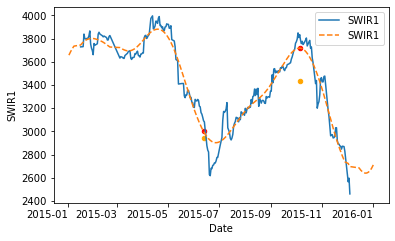

In [68]:
ID = 'CN_P2'
var = 'SWIR1'
ax1 = df_yr[(df_yr['Id'] == ID)].plot(x='Date', y=var)
df_yr_ts[(df_yr_ts['Id'] == ID)].plot(x='Date', y=var, ax=ax1, linestyle='dashed')
df_out_old[(df_out_old['Id'] == ID) & 
           (df_out_old['Year'] == 2015)].plot.scatter(x='Date', y=var, c='orange', ax=ax1)
df_out[(df_out['Id'] == ID) & 
           (df_out['Year'] == 2015)].plot.scatter(x='Date', y=var, c='red', ax=ax1)

In [59]:
dates_missing

[datetime.date(2013, 1, 2),
 datetime.date(2013, 1, 3),
 datetime.date(2013, 1, 4),
 datetime.date(2013, 2, 23),
 datetime.date(2013, 2, 24),
 datetime.date(2013, 2, 25),
 datetime.date(2013, 2, 26),
 datetime.date(2013, 10, 19),
 datetime.date(2013, 12, 7),
 datetime.date(2013, 12, 8),
 datetime.date(2013, 12, 9),
 datetime.date(2013, 12, 10),
 datetime.date(2013, 12, 11)]

<AxesSubplot:xlabel='Date'>

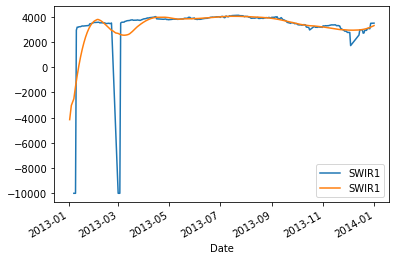

In [63]:
ax1 = df_yr[(df_yr['Id'] == '25NW_P1')].plot(x='Date', y='SWIR1')
df_yr_ts[(df_yr_ts['Id'] == '25NW_P1')].plot(x='Date', y='SWIR1', ax=ax1)

In [22]:
yr = 2014
from glob import glob
lmfPATH_yr = glob(os.path.join(lmfDIR, 'CPER_' + str(yr) + '*.nc'))
#lmfFILE_list = glob(os.path.join(lmfDIR_yr[0], '*.bin'))

In [7]:
bbox = gdf_vor.total_bounds

In [8]:
lmf_ds = riox.open_rasterio(lmfPATH_yr[0], 
                          nodata=-9999, mask=True).sel(x=slice(bbox[0], bbox[2]),
                                                       y=slice(bbox[3], bbox[1])).load()

Warning 1: +init=epsg:XXXX syntax is deprecated. It might return a CRS with a non-EPSG compliant axis order.


In [9]:
lmf_ds = lmf_ds.chunk({'DOY': -1, 'y': 50, 'x': 50})

In [10]:
# create an xarray mask from the ground data
mask_info = gdf_vor.drop_duplicates(
    subset=['Id', 'Date'])[['Id', 'geometry']].reset_index(drop=True).reset_index().rename(
    columns={'index': 'id'})
mask_shp = [(row.geometry, row.id+1) for _, row in mask_info.iterrows()]
plot_mask = shp2mask(shp=mask_shp, 
                     transform=lmf_ds.rio.transform(), 
                     outshape=lmf_ds['BLUE'].shape[1:], 
                     xr_object=lmf_ds['BLUE'])
mask_dict = {row.id+1: row.Id for _, row in mask_info.iterrows()}
mask_dict[0] = 'UNK'
plot_mask = np.array([mask_dict[i] for i in plot_mask.values.flatten()]).reshape(plot_mask.shape)

In [11]:
# assign the plot id's to the xarray dataset
lmf_ds = lmf_ds.assign(Plot=(['y', 'x'], plot_mask)).chunk({'y': 50, 'x': 50})
lmf_ds = lmf_ds.set_coords('Plot')

# mask out areas outside ground plots
lmf_ds = lmf_ds.where(lmf_ds['Plot'] != 'UNK')

# lazy compute all vegetation indices
for vegidx in veg_dict:
    lmf_ds[vegidx] = veg_dict[vegidx](lmf_ds)

# convert to dataframe at plot scale
df_yr = lmf_ds[list(veg_dict.keys()) + band_list].groupby('Plot').mean('stacked_y_x').to_dataframe().reset_index()

In [22]:
df_yr['time'] = df_yr['DOY'].apply(lambda x: datetime(yr, 1, 1) + timedelta(days=x))
df_yr = df_yr.drop(columns=['DOY'])

In [26]:
start_date = df_yr['time'].min()
end_date = df_yr['time'].max()

In [28]:
# remove all non-plot data
df_yr = df_yr[df_yr['Plot'] != 'UNK']

# rename columns to match VOR data
df_yr = df_yr.rename(columns={'time': 'Date',
                              'Plot': 'Id'})

# get missing dates for gap-filling
dates_missing = [x for x in pd.date_range(start_date, end_date).date if x not in df_yr['Date'].unique()]

# convert missing dates to a dataframe for combining with veg index data
df_missing = pd.DataFrame({
    'Id': list(chain.from_iterable([list(np.repeat(x, len(dates_missing))) for x in df_yr['Id'].unique()])),
    'Date': list(chain.from_iterable(dates_missing for x in df_yr['Id'].unique()))})

# combine into one dataframe for gapfilling
df_yr_ts = pd.concat([df_yr, df_missing]).sort_values(['Id', 'Date'])

# smooth all vegetation indices to gapfill
for vegidx in veg_dict:
    df_yr_ts[vegidx + '_smooth'] = df_yr_ts.groupby('Id')[vegidx].transform(lambda x: double_savgol(x.values))
for band in band_list:
    df_yr_ts[band + '_smooth'] = df_yr_ts.groupby('Id')[band].transform(lambda x: double_savgol(x.values))

# convert date to datetime
df_yr_ts['Date'] = pd.to_datetime(df_yr_ts['Date'])

# rename smoothed columns and drop originals
df_yr_ts = df_yr_ts.drop(columns=list(veg_dict.keys()) + band_list)
col_rename_dict = {c: re.sub('_smooth', '', c) for c in df_yr_ts.columns if '_smooth' in c}
df_yr_ts = df_yr_ts.rename(columns=col_rename_dict)

<AxesSubplot:xlabel='DOY', ylabel='NDVI'>

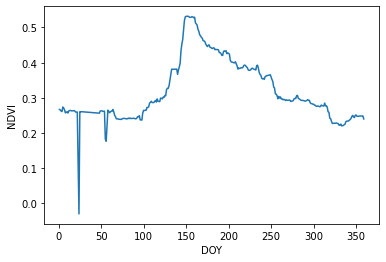

In [14]:
import seaborn as sns
sns.lineplot(x='DOY', y='NDVI', data=df_yr[df_yr['Plot'] == '10S_P1'])

<AxesSubplot:xlabel='Date', ylabel='DFI'>

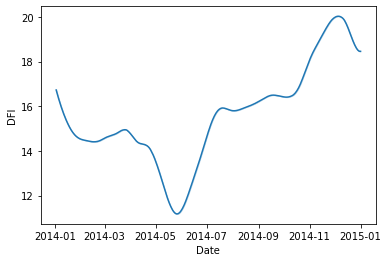

In [31]:
sns.lineplot(x='Date', y='DFI', data=df_yr_ts[df_yr_ts['Id'] == '10S_P1'])

In [9]:
import seaborn as sns

<AxesSubplot:xlabel='Date', ylabel='DFI'>

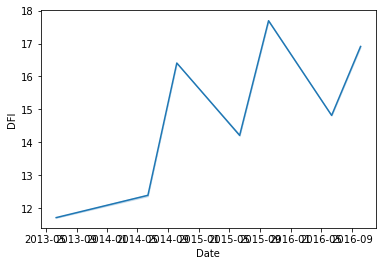

In [10]:
sns.lineplot(x='Date', y='DFI', data=df_out[df_out['Id'] == '10S_P1'])